In [76]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

In [77]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [78]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

In [79]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
#print(PV_data.head())

In [80]:
CF_solar = PV_data.mean(axis = 1) # average all the years

In [81]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()


In [82]:
CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets

In [83]:
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")
gas_price_pre_oct_2021.tail()

,GasDay,Created,BalanceType,Balance,ProductCode,greenZoneMin,greenZoneMax,YellowZoneMin,YellowZoneMax,GasBuyingPriceDKK,GasBuyPriceDescription,GasSellingPriceDKK,GasSellPriceDescription
15861,2022-09-30 00:00:00,2022-10-01 01:45:15,ESCB,3166032,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15862,2022-09-30 00:00:00,2022-09-30 22:45:23,ESCB,3537232,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15863,2022-09-30 00:00:00,2022-10-31 07:28:17,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15864,2022-09-30 00:00:00,2022-11-09 13:28:53,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15865,2022-09-30 00:00:00,2022-09-30 06:46:05,ESCB,-4450243,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN


In [84]:
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]

In [85]:
gas_price_data = pd.read_excel(gas_file)

In [86]:
# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [87]:
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)

In [88]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

In [89]:
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])

In [90]:
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

In [91]:
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh

In [92]:
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}

In [93]:
def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    # 1. Year Filter & Column Selection (Fixes DateParseError)
    year_str = str(year)
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # 2. Settings & Conversion (øre/kWh to EUR/MWh)
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45 
    
    # 3. Define Logic Windows
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_peak_time = hours.hour.isin(range(17, 21)) # 17:00 to 20:59
    is_day_time = hours.hour.isin(range(6, 24))   # 06:00 to 23:59

    # 4. Apply Net Tariff Levels
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    net_tariff.loc[is_day_time] = d["el_tariff_high"]
    net_tariff.loc[is_winter & is_peak_time] = d["el_tariff_peak"]

    # 5. Calculate Final Prices
    fixed_fees = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    buy_price = spot + (fixed_fees + net_tariff) * DKK_to_EUR_MWh
    
    # Selling = Spot minus production costs
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price
    

In [94]:
import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")

In [95]:
def plot_pypsa_heatmap(data, title="PyPSA Heatmap", unit="Value", cmap="viridis", ax=None, vmin=None, vmax=None):
    """
    Added vmin and vmax for manual scale control.
    """
    if isinstance(data, pd.DataFrame):
        plot_data = data.mean(axis=1)
    else:
        plot_data = data

    df = plot_data.to_frame(name="values")
    df["date"] = df.index.date
    df["hour"] = df.index.hour
    
    pivot = df.pivot_table(index="date", columns="hour", values="values", aggfunc='mean')

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Pass vmin and vmax here
    sns.heatmap(pivot, cmap=cmap, cbar_kws={'label': unit}, ax=ax, 
                rasterized=True, vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Date")

In [96]:
def add_carriers(n):
    #n.add("Carrier",'electricity grid im')
    #n.add("Carrier","electricity grid ex") 
    n.add("Carrier","onshorewind")
    n.add("Carrier","solar")
    n.add("Carrier","electric boiler")
    #n.add("Carrier","Rondo charge")
    #n.add("Carrier","Rondo store")
    #n.add("Carrier","Rondo discharge")
    n.add("Carrier","heat")
    n.add("Carrier","battery storage")
    n.add("Carrier","electricity")
    n.add("Carrier","gas") # co2_emissions=0.206tonnes/MWh   # for NG boiler # Assume that methane gas emits 0.198 tCO2 per MWh of thermal energy contained in the gas. 
    n.add("Carrier", "pellets") 
    n.add("Carrier", "CO2", unit = "t/h") #co2_emissions=-0.164 (tCO2/MWh_pell) #for biochar # -0.164 ????
    n.add("Carrier", "pyrolysis")
    n.add("Carrier", "hydrogen")
    n.add("Carrier", "methanol")
    n.add("Carrier", "methanolisation")
    n.add("Carrier", "electrolysis")
    n.add("Carrier", "digestate")
    
    n.add("Carrier", "biomass", unit = "t/h")
    n.add("Carrier", "biochar")
    n.add("Carrier", "methane")

In [97]:
def add_skive_generators(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "Greenlab" , # Greenlab , EuroWind
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 30)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "Greenlab",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54)

In [171]:
def add_grid(n, price_import, price_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          efficiency=1.0,
          marginal_cost=5e-6,
          capital_cost=0.0,
          carrier="electricity")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="Greenlab",   # [EuroWind or Greenlab]
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="electricity")

    n.add("Link", "Exports",
          bus0="Greenlab",   # [EuroWind or Greenlab]
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_export)

In [99]:
def add_battery(n,P_nom, max_t, cyclic_operation = False):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="Greenlab",  # Use your electricity bus name {EuroWind, Greenlab}
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [100]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        #e_nom= e_nom_store, # MWh
        e_nom_extendable=True,
        e_nom_min = e_nom_store,
        e_nom_max = e_nom_store,
        e_cyclic=False,
        standing_loss= 1.2/100, # 1.2% per hour
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=True,
        p_nom_min = p_nom_charge,
        p_nom_max = p_nom_charge, 
        # p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Exchanger_Bus",
        #p_nom = p_nom_discharge,
        p_nom_extendable=True,
        p_nom_min = p_nom_discharge,
        p_nom_max = p_nom_discharge,
        efficiency=0.90,
        carrier = "heat",
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])


# 2 Heat Exchanger hence effincecy = 0.9*0.9 = 0.81
def add_heat_exchanger(n):
    n.add("Link", "Heat_Exchanger_Rondo",
     bus0="Heat_Exchanger_Bus",
     bus1="Heat_MT", 
     carrier="heat", 
     p_nom_extendable=True , 
     efficiency=0.8)

In [101]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        #p_nom = 10, # MW,
        p_nom_extendable = True,
        p_nom_min = 10,
        p_nom_max = 10,
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"],
        marginal_cost = costs.at["electric boiler steam","marginal_cost"])

In [102]:
def add_NG_boiler(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        capital_cost = costs.at["decentral gas boiler","capital_cost"],
        marginal_cost = NG_price + CO2tax, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,) 

file:///C:/Users/Pulin/Downloads/technology_data_for_renewable_fuels_14.pdf

- if pellets come from biogas plant, the must be dried/pelletized


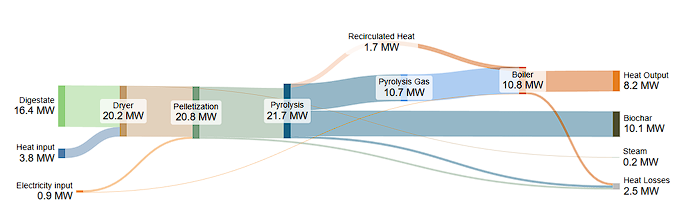

- assuming we produce 0.12 MW of pellets after dewatering and pelletisation

- Digestate Output:

1.98 t/h * 16.5 MJ/kg = 1980 MJ/h = 9.075 MW

In [104]:
# E_density_Digestate = 16.5 MJ/kg
# digestate_production 1 t/h = 1000 kg/h

def digestate_treatment(n):
    n.add("Link", "Drying and Pelletization",
        bus0 = "pellets",      # Output (Reference: 20.8 MW)
        bus1 = "Digestate",    # Input: Raw Digestate (16.4 MW)
        bus2 = "Greenlab",     # Input: Electricity (0.6 MW)
        bus3 = "Heat_MT",      # Input: Heat (3.8 MW)
        p_nom_extendable = True,
        
        # All inputs must be NEGATIVE and use the same denominator (20.8)
        
        efficiency1 = -16.4 / 20.8, # Digestate required per MW of pellet
        efficiency2 = -0.6 / 20.8,  # Electricity required per MW of pellet
        efficiency3 = -3.8 / 20.8   # Heat required per MW of pellet
    )

In [162]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t

    n.add("Store",
    "pellets store",
     bus = "pellets",
     carrier = "pellets",
     e_nom_extendable = True)
    
    # straw pellets cost from 35 - 82 EUR/ton
    # LHV_pellets = 16 MJ/kg
    

    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="biochar",
        p_nom_extendable=False,
        efficency = 8.2/21.7, # MW
        efficency2 = 10.1/21.7, # MW
        p_nom=2,
        carrier="pyrolysis",
        capital_cost=costs.at["biochar pyrolysis","capital_cost"]) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom_extendable = True,
        marginal_cost=-0.164*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="biochar") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="biochar")

- Simplifying the Biogas Plant:

- assuming it runs at constant load/production

In [106]:
# Constant Operation of Plant
def biogas_plant_simple(n):

    n.add("Load", "Biogas_el_load",
            bus = "Greenlab",
            carrier = "electrcity",
            p_set = 2 # MW
            )

    n.add("Load", "Biogas_heat_load",
            bus = "Heat_MT",
            carrier = "heat",
            p_set = 5 # MW
            )   
    n.add("Load", "Dewatering_Digestate",
            bus = "Greenlab",
            carrier = "electricty",
            p_set = 0.8 # MW
            )
   
    n.add("Store", "Biogas_feedstock_supply",
        bus = "Biogas_Feedstock",
        carrier = "biomass",
        e_initial = 500*1e3, # t
        e_cylic = False
        )

    n.add("Load", "Biogas_feedstock_load",
            bus = "Biogas_Feedstock",
            p_set = 209 # t/h
                ) 
    
    n.add("Load", "Biogas_upgrading_heat",
                bus = "Heat_MT",
                carrier = "heat",
                p_set = 0.1 # MW
                 )
    n.add("Load", "Biogas_upgrading_electrcity",
                bus = "Greenlab",
                p_set = 2 # MW
                )

#------------------------------------------------
    #LHV_digestate_dried = 16 # MJ/kg

    n.add("Generator", "Biogas_production",
            bus = "Methane",
            carrier = "methane",
            p_nom = 100, # MW
            )
    n.add("Generator", "Co2_production",
                bus = "Co2",
                carrier = "CO2",
                p_nom= 10 # t/h
                )
    n.add("Generator","Biogas_pellets_byproduct",
        bus = "pellets",
        carrier = "pellets",
        p_set = 12 # MW
        )


In [107]:
209/2.09

100.0

- Biogas Plant can Produce 25 - 30 MW of biogas (CH4)

for every MW of biogas we need 2.08 t/h feedstock

In [142]:
    # Fixed Load for Biogas Plant
    def biogas_plant_simple(n):

        n.add("Store","Biomass Store",
            bus = "Biogas_Feedstock",
            e_nom = 500000 ,
            e_initial = 500000, # t
            e_min_pu = 0,
            e_cyclic = False,
            carrier = "biomass",
            marginal_cost = 0)

        n.add("Link",
            "BiogasPlant",
            bus0 = "Biogas_Feedstock", # input: Feedstock
            bus1 = "Greenlab", # input: electrcity
            bus2 = "Heat_MT", # input: heat
            bus3 = "pellets", # output: Pellets
            bus4 = "Biogas", # ouptut: CH4 
            bus5 = "Co2", # output: Co2
            carrier = "BiogasPlant",
            p_nom_extendable = False,
            p_nom = 63, # t/h
            p_min_pu = 0.8,
            p_max_pu = 1,
            capital_cost = costs.at["biogas","capital_cost"],
            efficiency =  -(0.02 + 0.008 + 0.02)/2.09, # el input (MW) } auxillary + dewatering + upgrading 
            efficiency2 = -(0.05 + 0.1)/2.09, # heat input (MW) } auxillary + upgrading
            efficiency3 =  0.12/2.09, # Pellets output (MW)) 
            efficiency4  = 1/2.09,  # Biogas (CH4) output (MW)
            efficiency5 = 0.1/2.09, # co2 (t/h)
        )

        
        n.add("Store", "Biogas_Store",
            bus = "Biogas",
            marginal_cost = 0,
            carrier = "methane",
            e_nom_extendable = True,)

        n.add("Store", "Co2_Store",
        bus = "Co2",
        carrier = "CO2",
        e_nom_extendable = True,
        )

In [109]:
eff_h2 = 1 / costs.at["methanolisation", "hydrogen-input"]

In [132]:
def add_methanolisation(n, p_min):
    n.add("Link",
     "methanolisation",
     bus0 = "H2_Bus",
     bus1 = "methanol_bus",
     bus2 = "Greenlab",
     bus3 = "Co2",  # Co2 from byproduct of biogas plant
     #p_nom = 10, # 10 MW methanol plant,
     p_nom_extendable = True,
     p_min_pu = p_min,
     carrier = "methanolisation",
     capital_cost = costs.at["methanolisation", "capital_cost"]*eff_h2,
     efficiency = eff_h2, # 0.87 , methanol output 
     efficiency2 = -costs.at["methanolisation", "electricity-input"]*eff_h2, # - 0.23 , electricty input
     efficiency3 = -costs.at["methanolisation", "carbondioxide-input"]*eff_h2 , # - 0.218 t/h , Co2 input
     )

    n.add("Store",
    "methanol storage",
    bus="methanol_bus",
    carrier="methanol",
    capital_cost=costs.at["General liquid hydrocarbon storage (crude)", "capital_cost"] / (15.6 * 1000 / 3600),
    e_nom_extendable=True,
    e_cyclic=False,)

In [114]:
"Adding Electrolyser"
def add_electrolyser(n, P_elec):
    n.add("Link",
    "Electrolyser",
    bus0 = "Greenlab",
    bus1 = "H2_Bus",
    p_nom = P_elec,
    p_nom_extendable = True,
    carrier = "electrolysis",
    p_min_pu = 0.15,
    #p_nom_min = , 
    #p_nom_max = ,
    capital_cost = costs.at["Alkaline electrolyzer medium size", "capital_cost"],
    marginal_cost = costs.at["Alkaline electrolyzer medium size", "marginal_cost"],
    efficiency = 0.6,)

    n.add("Store",
    "H2_Storage",
    bus = "H2_Bus",
    capital_cost = costs.at["hydrogen storage tank type 1 including compressor", "capital_cost"],
    e_nom_extendable = True,
    carrier = "hydrogen",
    e_cylic = True)

In [178]:
def build_network(CO2_tax, p_import, p_export, NG_price, horizon, overlap):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    
    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    add_carriers(n)

    n.add("Carrier","BiogasPlant")
    
    n.add("Bus", "Greenlab", carrier="electricity")

    n.add("Bus", "Grid_Import", carrier="electricity")
    n.add("Bus", "Grid_Export", carrier="electricity")

    n.add("Bus", "NG", carrier="gas")

     # Heat & Solids
    n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")
    #n.add("Bus", "Digestate", carrier = "digestate")
    
    n.add("Bus", "H2_Bus", carrier="hydrogen")
    n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "Biogas", carrier="methane")
    n.add("Bus", "Co2", carrier="CO2")
    

    add_grid(n, price_import = p_import, price_export = p_export)



    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")
    n.add("Bus", "methanol_bus", carrier = "methanol")

    add_battery(n, P_nom=22, max_t=2, cyclic_operation=False)
    add_skive_generators(n, s_cf, w_cf)

    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)

    biogas_plant_simple(n)
    #digestate_treatment(n)
    add_electrolyser(n, P_elec = 12)
    add_SkyClean(n, CO2tax = 0)

    add_methanolisation(n, p_min = 0.1)


    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            assign_all_duals = True,
            solver_name="gurobi", 
            horizon=horizon, overlap = overlap)
    else:
        # Full Year Optimization
        n.optimize(assign_all_duals = True,
            solver_name="gurobi",)

    return n

In [179]:
n21 = build_network(CO2_tax = 80, p_import = import_price21, p_export = export_price21, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00,  9.53it/s]
INFO:linopy.io: Writing time: 7.78s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 38303 iterations and 9.66 seconds (13.13 work units)


INFO:gurobipy:Solved in 38303 iterations and 9.66 seconds (13.13 work units)


Optimal objective -9.382253788e+06


INFO:gurobipy:Optimal objective -9.382253788e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 332670 primals, 726603 duals
Objective: -9.38e+06
Solver model: available
Solver message: 2



In [193]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_heat_summary(n, load_name="Heat_Load_MT", title="Heat Production Mix", 
                      show_stats=True):
    """
    Plots a stacked area chart for your standard Skive/GreenLab heat links.
    """
    # Define your standard links and colors as the 'source of truth'
    standard_links = {
        "Boiler Skive": "Boiler_Skive",
        "NG Boiler": "NG boiler",
        "Pyrolysis": "pyrolysis",
        "Heat Exchanger Rondo": "Heat_Exchanger_Rondo"
    }
    colors = ["orange", "blue", "green", "red"]
    
    # 1. Extract and invert the p1 data (converts consumption to production)
    data = {}
    for label, py_name in standard_links.items():
        if py_name in n.links_t.p1.columns:
            data[label] = -n.links_t.p1[py_name]
    
    df = pd.DataFrame(data)

    # 2. Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    df.plot.area(ax=ax, color=colors, alpha=0.8, lw=0)

    # 3. Add the Demand Line
    if load_name in n.loads_t.p_set.columns:
        n.loads_t.p_set[load_name].plot(ax=ax, color="black", lw=1.5, 
                                        ls="--", label="Heat Demand")

    # 4. Formatting
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Heat [MW]")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
    plt.tight_layout()
    
    # 5. Print Energy Stats (MWh to GWh)
    if show_stats:
        print(f"\n--- Annual Energy Production (GWh) ---")
        # Sum MW over time and divide by 1000 to get GWh
        stats = df.sum() / 1000 
        print(stats)
        
    return ax

<Axes: xlabel='snapshot'>

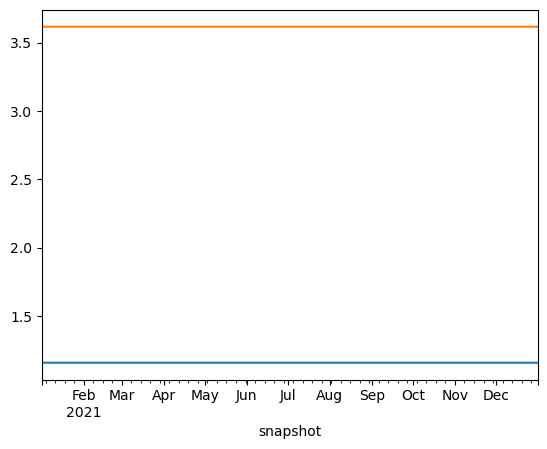

In [168]:
n21.links_t.p1["BiogasPlant"].plot()
n21.links_t.p2["BiogasPlant"].plot()

In [146]:
n21.links

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,bus5,efficiency5,bus4,efficiency4,bus3,efficiency3,bus2,efficiency2,efficency,efficency2
Link,,,,,,,,,,,,,,,,,,,,,
El_to_TES_Rondo,Greenlab,TES_Rondo,,electricity,0.980000,True,0,inf,0.0,0.0,...,,1.000000,,1.000000,,1.000000,,1.000000,NaN,NaN
TES_Rondo_to_Heat_Bus_Skive,TES_Rondo,Heat_Exchanger_Bus,,heat,0.900000,True,0,inf,0.0,0.0,...,,1.000000,,1.000000,,1.000000,,1.000000,NaN,NaN
Heat_Exchanger_Rondo,Heat_Exchanger_Bus,Heat_MT,,heat,0.800000,True,0,inf,0.0,0.0,...,,1.000000,,1.000000,,1.000000,,1.000000,NaN,NaN
Boiler_Skive,Greenlab,Heat_MT,,electric boiler,0.900000,True,0,inf,0.0,0.0,...,,1.000000,,1.000000,,1.000000,,1.000000,NaN,NaN
NG boiler,NG,Heat_MT,,gas,0.980000,True,0,inf,6.0,0.0,...,,1.000000,,1.000000,,1.000000,,1.000000,NaN,NaN
BiogasPlant,Biogas_Feedstock,Greenlab,,BiogasPlant,-0.022967,True,0,inf,63.0,0.0,...,Co2,0.047847,Biogas,0.478469,pellets,0.057416,Heat_MT,-0.071770,NaN,NaN
Electrolyser,Greenlab,H2_Bus,,electrolysis,0.600000,True,0,inf,12.0,0.0,...,,1.000000,,1.000000,,1.000000,,1.000000,NaN,NaN
pyrolysis,pellets,Heat_MT,,pyrolysis,1.000000,True,0,inf,2.0,0.0,...,,1.000000,,1.000000,,1.000000,biochar,1.000000,0.37788,0.465438
biochar sequestration,biochar,biochar sequestration,,biochar,1.000000,True,0,inf,0.0,0.0,...,,1.000000,,1.000000,,1.000000,,1.000000,NaN,NaN


<Axes: xlabel='snapshot'>

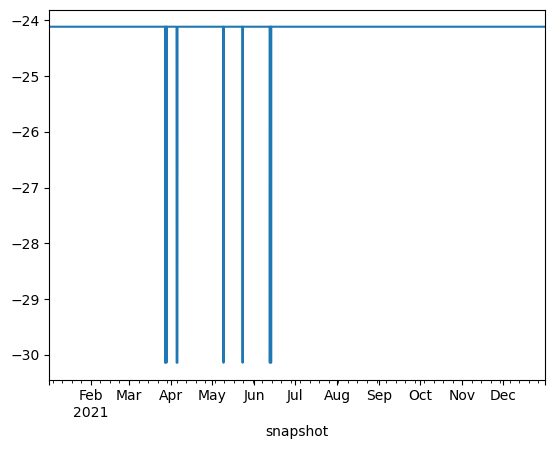

In [180]:
n21.links_t.p4["BiogasPlant"].plot()

In [181]:
n21.statistics()

Optimal Capacity  Installed Capacity  \
Generator   electricity              54.09362                 0.0   
            gas                       6.00000                 6.0   
            onshorewind              54.00000                54.0   
            solar                    30.00000                30.0   
Link        BiogasPlant              63.00000                63.0   
            biochar                   2.00000                 0.0   
            electric boiler          10.00000                 0.0   
            electricity             192.00000               168.0   
            electrolysis              0.00000                12.0   
            gas                       6.00000                 6.0   
            heat                     12.65191                 0.0   
            pyrolysis                 2.00000                 2.0   
StorageUnit battery storage          22.00000                22.0   
Store       CO2                   21125.19617                 0.0   
            biochar               17458.00000                 0.0   
            biomass              500000.00000            500000.0   
            electricity          111246.35716                 0.0   
            heat                    100.00000                 0.0   
            methane              211251.96172                 0.0   
            pellets                7892.23541                 0.0   

                                   Supply    Withdrawal  Energy Balance  \
Generator   electricity        3366.60513       0.00000      3366.60513   
            gas                1591.37882       0.00000      1591.37882   
            onshorewind      111990.52477       0.00000    111990.52477   
            solar             30293.84375       0.00000     30293.84375   
Link        BiogasPlant           0.00000  441516.60000   -441516.60000   
            biochar               0.00000   17458.00000    -17458.00000   
            electric boiler       0.00000    8911.14658     -8911.14658   
            electricity           0.00000  126307.91246   -126307.91246   
            electrolysis          0.00000       0.00000         0.00000   
            gas                   0.00000    1591.37882     -1591.37882   
            heat                  0.00000   12271.39037    -12271.39037   
            pyrolysis             0.00000   17458.00000    -17458.00000   
StorageUnit battery storage   22372.83948   25930.26690     -3557.42743   
Store       CO2                   0.00000   21125.19617    -21125.19617   
            biochar               0.00000   17458.00000    -17458.00000   
            biomass          441516.60000       0.00000    441516.60000   
            electricity           0.00000  111246.35716   -111246.35716   
            heat               6218.34164    7848.96948     -1630.62784   
            methane               0.00000  211251.96172   -211251.96172   
            pellets               0.00000    7892.23541     -7892.23541   

                             Transmission  Capacity Factor   Curtailment  \
Generator   electricity           0.00000         0.007110  470168.96237   
            gas                   0.00000         0.030298   50932.62118   
            onshorewind           0.00000         0.236909    2454.48253   
            solar                 0.00000         0.115352     254.62225   
Link        BiogasPlant           0.00000         0.800571       0.00000   
            biochar           17458.00000         0.997145       0.00000   
            electric boiler       0.00000         0.101795       0.00000   
            electricity      118053.57128         0.075149       0.00000   
            electrolysis          0.00000         0.000000       0.00000   
            gas                   0.00000         0.030298       0.00000   
            heat              12271.39037         0.110798       0.00000   
            pyrolysis             0.00000         0.997145       0.00000   
StorageUnit bat

<Axes: xlabel='snapshot'>

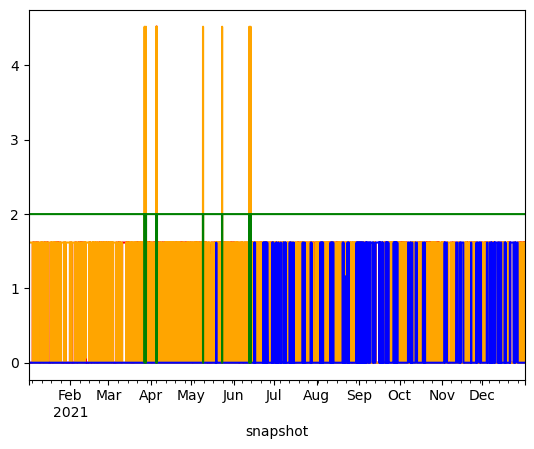

In [182]:
(-n21.links_t.p1["Heat_Exchanger_Rondo"]).plot(color = "red")
(-n21.links_t.p1["Boiler_Skive"]).plot(color = "orange")
(-n21.links_t.p1["NG boiler"]).plot(color = "blue")
(-n21.links_t.p1["pyrolysis"]).plot(color = "green")

In [183]:
n22 = build_network(CO2_tax = 80, p_import = import_price22, p_export = export_price22, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2022"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00,  9.47it/s]
INFO:linopy.io: Writing time: 7.75s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 41177 iterations and 9.37 seconds (13.10 work units)


INFO:gurobipy:Solved in 41177 iterations and 9.37 seconds (13.10 work units)


Optimal objective -2.526916627e+07


INFO:gurobipy:Optimal objective -2.526916627e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 332898 primals, 727101 duals
Objective: -2.53e+07
Solver model: available
Solver message: 2



<Axes: xlabel='snapshot'>

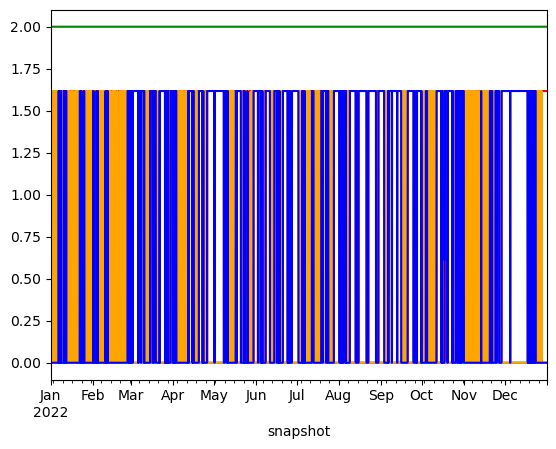

In [184]:
(-n22.links_t.p1["Heat_Exchanger_Rondo"]).plot(color = "red")
(-n22.links_t.p1["Boiler_Skive"]).plot(color = "orange")
(-n22.links_t.p1["NG boiler"]).plot(color = "blue")
(-n22.links_t.p1["pyrolysis"]).plot(color = "green")

In [185]:
n23 = build_network(CO2_tax = 80, p_import = import_price23, p_export = export_price23, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2023"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00,  9.41it/s]
INFO:linopy.io: Writing time: 7.61s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 39152 iterations and 14.22 seconds (17.21 work units)


INFO:gurobipy:Solved in 39152 iterations and 14.22 seconds (17.21 work units)


Optimal objective -1.008579978e+07


INFO:gurobipy:Optimal objective -1.008579978e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 332898 primals, 727101 duals
Objective: -1.01e+07
Solver model: available
Solver message: 2



In [ ]:
n23 = build_network(CO2_tax = 80, p_import = import_price23, p_export = export_price23, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2023"], horizon = None, overlap = None)

<Axes: xlabel='snapshot'>

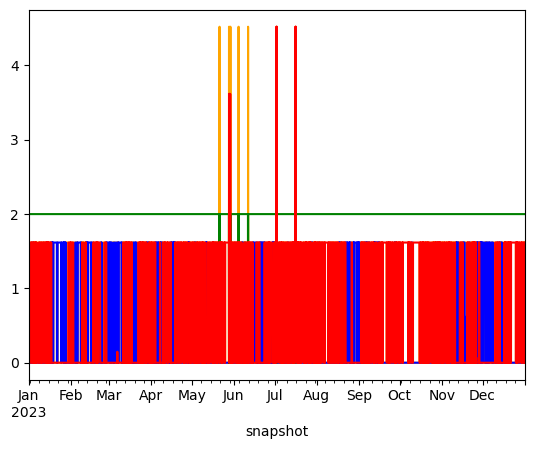

In [191]:
(-n23.links_t.p1["Boiler_Skive"]).plot(color = "orange")
(-n23.links_t.p1["NG boiler"]).plot(color = "blue")
(-n23.links_t.p1["pyrolysis"]).plot(color = "green")
(-n23.links_t.p1["Heat_Exchanger_Rondo"]).plot(color = "red")

<Axes: xlabel='snapshot'>

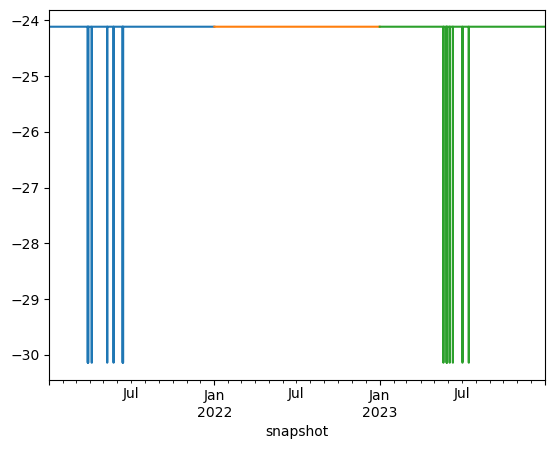

In [ ]:
n21.links_t.p4["BiogasPlant"].plot()
n22.links_t.p4["BiogasPlant"].plot()
n23.links_t.p4["BiogasPlant"].plot()
n21.links_t.p4["BiogasPlant"].plot()


--- Annual Energy Production (GWh) ---
Boiler Skive             8.020032
NG Boiler                1.559551
Pyrolysis               17.458000
Heat Exchanger Rondo     4.650211
dtype: float64

--- Annual Energy Production (GWh) ---
Boiler Skive             3.054970
NG Boiler                6.478947
Pyrolysis               17.520000
Heat Exchanger Rondo     4.632973
dtype: float64

--- Annual Energy Production (GWh) ---
Boiler Skive             4.946160
NG Boiler                2.512913
Pyrolysis               17.444716
Heat Exchanger Rondo     6.808421
dtype: float64


NameError: name 'n24' is not defined

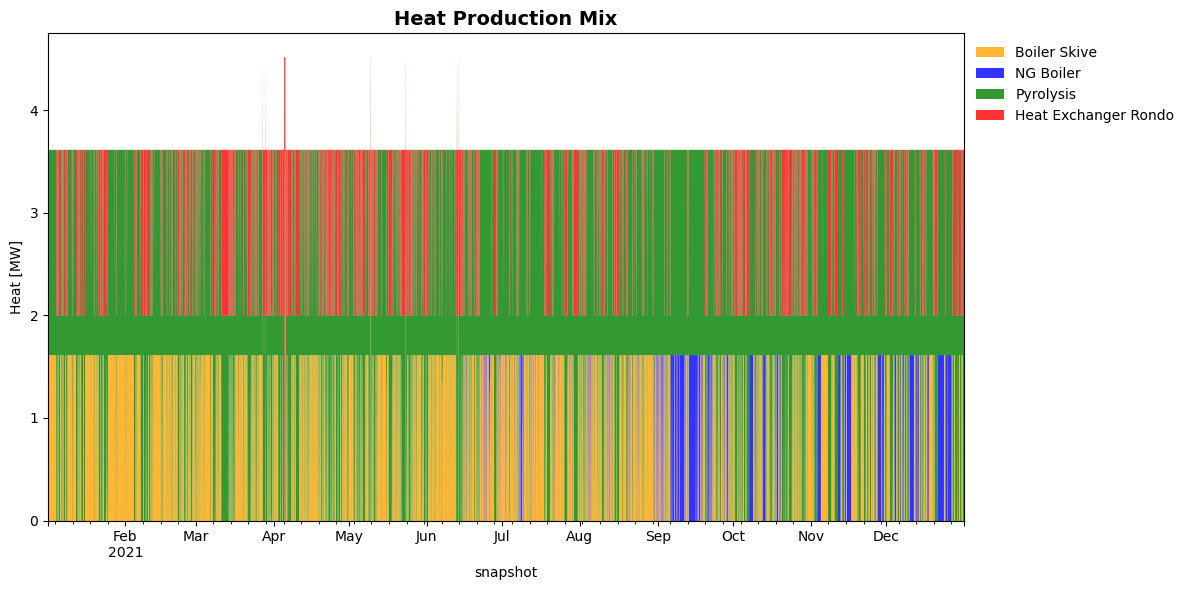

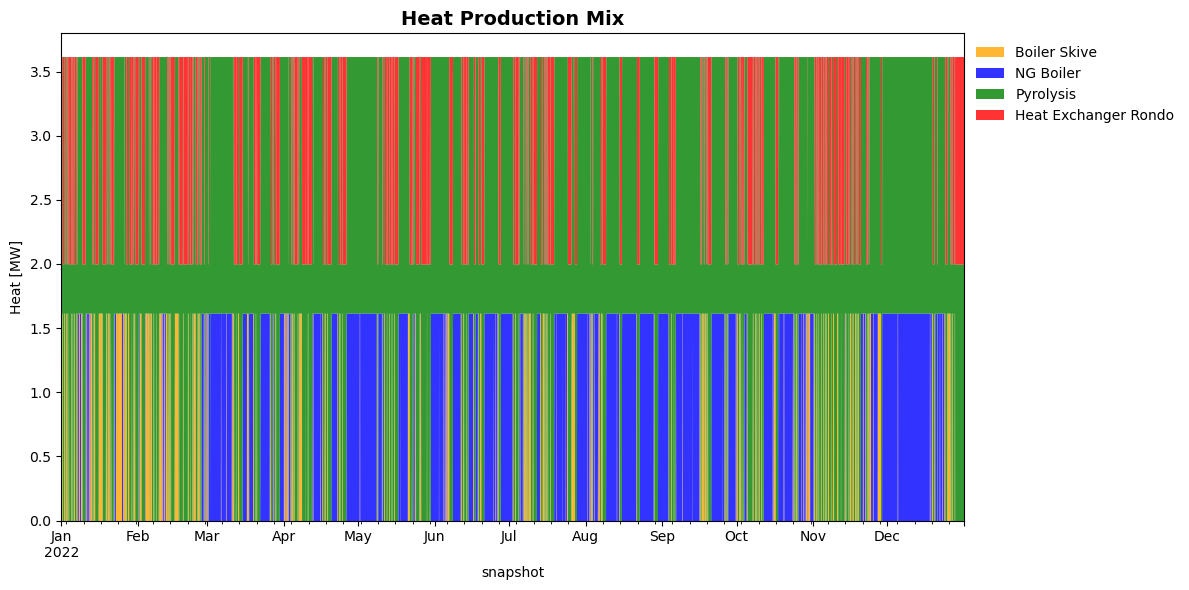

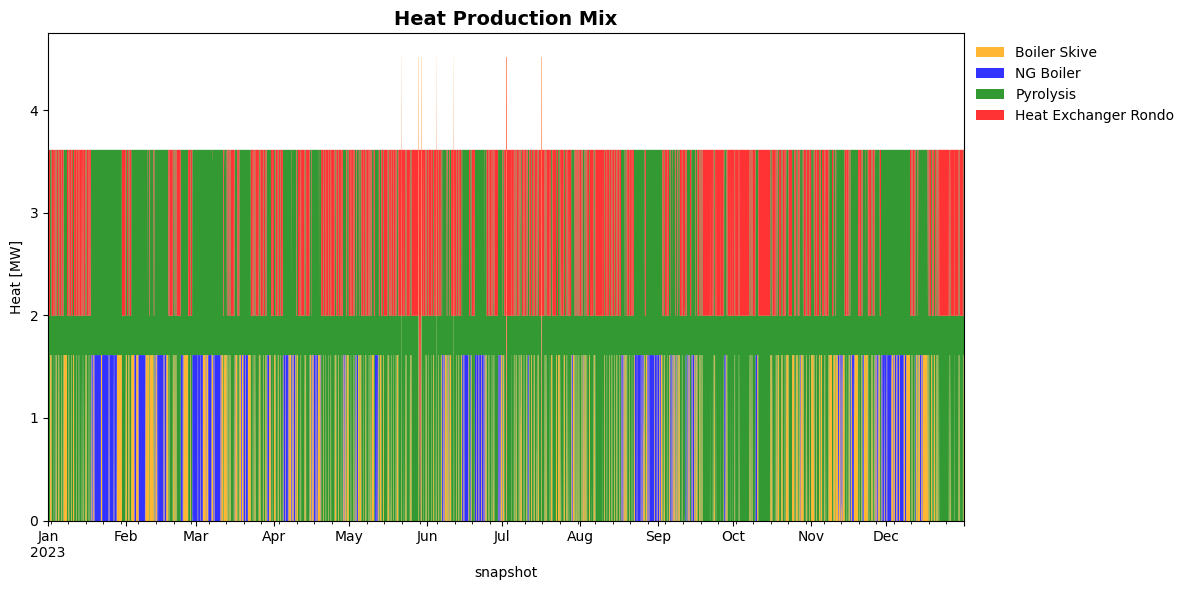

In [196]:
plot_heat_summary(n21)
plot_heat_summary(n22)
plot_heat_summary(n23)
plot_heat_summary(n24)